In [11]:
import pyomo.environ as pyo
import pandas as pd
import math
import numpy as np
from collections import defaultdict
from datetime import timedelta
from pyomo.util.infeasible import log_infeasible_constraints
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [31]:
class charging_point():
    def __init__(self, name, bus, ev_capacity, ev_max_power, ev_arrival_soc, ev_arrival, ev_departure, ev_desired_soc):
        self.efficiency = 0.93
        # Input validation using assertions
        #assert isinstance(bus, list), "ev_bus must be a list"
        assert isinstance(ev_capacity, list), "ev_capacity must be a list"
        assert isinstance(ev_max_power, list), "ev_max_power must be a list"
        assert isinstance(ev_arrival_soc, list), "ev_arrival_soc must be a list"
        assert isinstance(ev_arrival, list), "ev_arrival must be a list"
        assert isinstance(ev_departure, list), "ev_departure must be a list"
        assert isinstance(ev_desired_soc, list), "ev_desired_soc must be a list"

        assert len(ev_arrival) == len(ev_departure), "ev_arrival and ev_departure must have the same length"
        assert len(ev_arrival) == len(ev_desired_soc), "ev_arrival and ev_desired_soc must have the same length"
        assert len(ev_arrival_soc) == len(ev_desired_soc), "ev_arrival_soc and ev_desired_soc must have the same length"
        assert len(ev_capacity) == len(ev_desired_soc), "ev_capacity and ev_desired_soc must have the same length"
        assert len(ev_max_power) == len(ev_desired_soc), "ev_max_power and ev_desired_soc must have the same length"

        for i in range(len(ev_arrival)):
            assert ev_arrival[i] < ev_departure[i], f"ev_arrival[{i}] must be less than ev_departure[{i}]"
            assert 0.2 <= ev_arrival_soc[i] <= 1, f"ev_arrival_soc[{i}] must be between 0.2 and 1"
            assert 0 <= ev_desired_soc[i] <= 1, f"ev_desired_soc[{i}] must be between 0 and 1"
            min_time_to_charge = ev_departure[i] - ev_arrival[i]
            min_req_charge = (ev_desired_soc[i] - ev_arrival_soc[i]) * ev_capacity[i] / self.efficiency
            min_req_charge_per_time = min_req_charge / min_time_to_charge
            assert min_req_charge_per_time <= ev_max_power[i], f"min_req_charge_per_time ({min_req_charge_per_time:.2f}) must be less than or equal to ev_max_power[{i}] ({ev_max_power[i]}) for {name}"

        self.name = name
        self.ev_bus = bus
        self.bus_index = bus
        self.ev_capacity = ev_capacity
        self.ev_max_power = ev_max_power
        self.ev_arrival_soc = ev_arrival_soc
        self.ev_desired_soc = ev_desired_soc
        self.ev_arrival = ev_arrival
        self.ev_departure = ev_departure
        self.num_evs = len(ev_capacity) # Store the number of EVs

class building():
    def __init__(self, name, bus, load, pv_production, bess_capacity, bess_max_power, bess_initial_soc):
        self.efficiency = 0.93
        self.name = name
        self.bus_index = bus
        self.load = load
        self.pv_production = pv_production
        self.bess_capacity = bess_capacity
        self.bess_max_power = bess_max_power
        self.bess_initial_soc = bess_initial_soc

class V2G_opt_spot_cp_ldf():
    def __init__(self, charging_points, buildings, spot_prices, previous_monthly_peak=0, v2g_on=1, incentive_per_kwh=0.1):
        # Read network data from excel file
        self.lines_df = pd.read_excel(r"Data\network_data.xlsx", sheet_name="Lines")
        self.loads_df = pd.read_excel(r"Data\network_data.xlsx", sheet_name="Loads")
        self.base_df = pd.read_excel(r"Data\network_data.xlsx", sheet_name="BaseValues")
        # Initialize parameters
        self.M = 10000
        self.n_buses = self.loads_df["bus"].nunique()
        self.V_base = self.base_df.loc[self.base_df["Parameter"] == "V_base", "Value"].values[0]  # kV
        self.S_base = self.base_df.loc[self.base_df["Parameter"] == "S_base", "Value"].values[0]  # MVA
        self.Z_base = self.V_base ** 2 / self.S_base
        self.lines_df["r_pu"] = self.lines_df["r (ohm/km)"] / self.Z_base
        self.lines_df["x_pu"] = self.lines_df["x (ohm/km)"] / self.Z_base
        self.Pl = self.loads_df.set_index("bus")["P_load (MW)"] * 1000
        self.Ql = self.loads_df.set_index("bus")["Q_load (MVAr)"] * 1000

        self.charging_points = charging_points
        self.buildings = buildings
        self.spot_prices = spot_prices
        self.incentive_per_kwh = incentive_per_kwh
        self.v2g_on = v2g_on
        self.previous_monthly_peak = previous_monthly_peak
        self.model = pyo.ConcreteModel()
        self.build_model()

    def build_model(self):
        self.model.T = pyo.Set(initialize=range(len(self.spot_prices)))
        self.model.spot_prices = self.spot_prices
        self.model.P_im_grid = pyo.Var(self.model.T, within=pyo.NonNegativeReals, initialize=0, bounds=(0, 100000))
        self.model.P_ex_grid = pyo.Var(self.model.T, within=pyo.NonNegativeReals, initialize=0, bounds=(0, 100000))
        self.model.B_im_grid = pyo.Var(self.model.T, within=pyo.Binary)
        self.model.previous_monthly_peak = self.previous_monthly_peak
        self.model.monthly_peak = pyo.Var(initialize = 0)
        self.model.Peakload = pyo.Var(within=pyo.NonNegativeReals)
        self.model.transmission_cost = pyo.Var(self.model.T, within=pyo.Reals)
        self.model.supplier_cost = pyo.Var(self.model.T, within=pyo.Reals)
        self.model.overall_dso_cost = pyo.Var(self.model.T, within=pyo.Reals)
        self.model.tax_cost = pyo.Var(self.model.T, within=pyo.Reals)
        self.model.peak_cost = pyo.Var(self.model.T, within=pyo.Reals)
        self.model.Subscription_fee = 605/30  # Subscription fee SEK/14 days
        self.model.Transmission_fee = 0.113   # Electricity transmission fee SEK/kWh
        self.model.Transmission_health_incentive = 0.04 #Transmission health incentive SEK/kWh
        self.model.Effect_fee = 61.55/30       # Effect fee SEK/kW/14 days
        self.model.Energy_tax = 0.439           # Tax fee SEK/kWh
        self.model.Energy_certificate = 0.005   #Energy certificate SEK/kWh
        self.model.compensation_fee = 0.02    # Transfer compensation fee SEK/kWh
        self.model.BUSES = pyo.Set(initialize=range(self.n_buses))
        self.model.LINES = pyo.Set(initialize=[(int(row['from_bus']), int(row['to_bus'])) for _, row in self.lines_df.iterrows()])
        self.model.r = pyo.Param(self.model.LINES, initialize={(int(row['from_bus']), int(row['to_bus'])): row['r_pu'] for _, row in self.lines_df.iterrows()})
        self.model.x = pyo.Param(self.model.LINES, initialize={(int(row['from_bus']), int(row['to_bus'])): row['x_pu'] for _, row in self.lines_df.iterrows()})
        self.model.Pd = pyo.Param(self.model.T, self.model.BUSES,initialize={(t, b): self.Pl[b] for t in self.model.T for b in self.model.BUSES})
        self.model.Qd = pyo.Param(self.model.T, self.model.BUSES,initialize={(t, b): self.Ql[b] for t in self.model.T for b in self.model.BUSES})
        self.model.Pf = pyo.Var(self.model.T, self.model.LINES)
        self.model.Qf = pyo.Var(self.model.T, self.model.LINES)
        self.model.V2 = pyo.Var(self.model.T, self.model.BUSES, bounds=(0.9025,1.1025), initialize=1)


        # Voltage at the slack bus (bus 0)
        for t in self.model.T:
            self.model.V2[t, 0].fix(1.1025)


        for charge_point in self.charging_points:
            setattr(self.model, f'{charge_point.name}_P', pyo.Var(self.model.T, self.model.BUSES, within=pyo.Reals, bounds=(-1000000, 1000000)))

            # Iterate through each EV at the charging point
            for ev_index in range(charge_point.num_evs):
                ev_name = f'{charge_point.name}_ev{ev_index}'  # Unique name for each EV
                setattr(self.model, f'{ev_name}_ch', pyo.Var(self.model.T, within=pyo.NonNegativeReals, bounds=(0, charge_point.ev_max_power[ev_index])))
                setattr(self.model, f'{ev_name}_ds', pyo.Var(self.model.T, within=pyo.NonNegativeReals, bounds=(0, self.v2g_on * charge_point.ev_max_power[ev_index])))
                setattr(self.model, f'{ev_name}_soc', pyo.Var(self.model.T, within=pyo.NonNegativeReals, bounds=(0, 1)))
                setattr(self.model, f'{ev_name}_Bch', pyo.Var(self.model.T, within=pyo.Binary))

                ev_capacity = charge_point.ev_capacity[ev_index]
                ev_arrival_soc = charge_point.ev_arrival_soc[ev_index]
                ev_arrival = charge_point.ev_arrival[ev_index]
                ev_departure = charge_point.ev_departure[ev_index]
                ev_desired_soc = charge_point.ev_desired_soc[ev_index]

                def ev_soc_rule(model, t, charge_point=charge_point, ev_index=ev_index):
                    ev_ch = getattr(model, f'{ev_name}_ch')[t]
                    ev_ds = getattr(model, f'{ev_name}_ds')[t]
                    ev_soc = getattr(model, f'{ev_name}_soc')[t]
                    if t == ev_arrival:
                        return ev_soc == ev_arrival_soc + (ev_ch * charge_point.efficiency - ev_ds / charge_point.efficiency) / ev_capacity
                    elif ev_arrival < t <= ev_departure:
                        ev_previous_soc = getattr(model, f'{ev_name}_soc')[t - 1]
                        return ev_soc == ev_previous_soc + (ev_ch * charge_point.efficiency - ev_ds / charge_point.efficiency) / ev_capacity
                    else:
                        return pyo.Constraint.Skip
                setattr(self.model, f'{ev_name}_soc_constraint', pyo.Constraint(self.model.T, rule=ev_soc_rule))

                def ev_soc_min_rule(model, t, charge_point=charge_point, ev_index=ev_index):
                    ev_soc = getattr(model, f'{ev_name}_soc')[t]
                    ev_arrival = charge_point.ev_arrival[ev_index]
                    ev_departure = charge_point.ev_departure[ev_index]
                    if ev_arrival <= t <= ev_departure:
                        return ev_soc >= 0.2
                    return ev_soc == 0
                setattr(self.model, f'{ev_name}_soc_min_constraint', pyo.Constraint(self.model.T, rule=ev_soc_min_rule))

                def ev_max_ch(model, t, charge_point=charge_point, ev_index=ev_index):
                    ev_Bch = getattr(model, f'{ev_name}_Bch')[t]
                    ev_ch = getattr(model, f'{ev_name}_ch')[t]
                    return ev_ch <= ev_Bch * charge_point.ev_max_power[ev_index]
                setattr(self.model, f'{ev_name}_max_ch_constraint', pyo.Constraint(self.model.T, rule=ev_max_ch))

                def ev_max_ds(model, t, charge_point=charge_point, ev_index=ev_index):
                    ev_Bch = getattr(model, f'{ev_name}_Bch')[t]
                    ev_ds = getattr(model, f'{ev_name}_ds')[t]
                    return ev_ds <= (1 - ev_Bch) * charge_point.ev_max_power[ev_index]
                setattr(self.model, f'{ev_name}_max_ds_constraint', pyo.Constraint(self.model.T, rule=ev_max_ds))

                def ev_avail_ch(model, t, charge_point=charge_point, ev_index=ev_index):
                    ev_ch = getattr(model, f'{ev_name}_ch')[t]
                    if charge_point.ev_arrival[ev_index] < t < charge_point.ev_departure[ev_index]:
                        return ev_ch >= 0
                    return ev_ch == 0
                setattr(self.model, f'{ev_name}_avail_ch_constraint', pyo.Constraint(self.model.T, rule=ev_avail_ch))

                def ev_avail_ds(model, t, charge_point=charge_point, ev_index=ev_index):
                    ev_ds = getattr(model, f'{ev_name}_ds')[t]
                    if charge_point.ev_arrival[ev_index] < t < charge_point.ev_departure[ev_index]:
                        return ev_ds >= 0
                    return ev_ds == 0
                setattr(self.model, f'{ev_name}_avail_ds_constraint', pyo.Constraint(self.model.T, rule=ev_avail_ds))

                def ev_desired_soc(model, t, charge_point=charge_point, ev_index=ev_index):
                    ev_soc = getattr(model, f'{ev_name}_soc')[t]
                    if t == charge_point.ev_departure[ev_index]:
                        return ev_soc >= charge_point.ev_desired_soc[ev_index]
                    return pyo.Constraint.Skip
                setattr(self.model, f'{ev_name}_desired_soc_constraint', pyo.Constraint(self.model.T, rule=ev_desired_soc))

            def consumption(model, t, b, charge_point=charge_point):
                P = getattr(model, f'{charge_point.name}_P')[t, b]
                ev_power = sum(getattr(model, f'{charge_point.name}_ev{ev_index}_ch')[t] - getattr(model, f'{charge_point.name}_ev{ev_index}_ds')[t] for ev_index in range(charge_point.num_evs))
                if b == charge_point.bus_index:
                    return ev_power == P
                else:
                    return P == 0
            setattr(self.model, f'{charge_point.name}_consumption_constraint', pyo.Constraint(self.model.T, self.model.BUSES, rule=consumption))
        
        #Building constraints:
        for building in self.buildings:
            setattr(self.model, f'{building.name}_P', pyo.Var(self.model.T,  self.model.BUSES,within=pyo.Reals, bounds=(-1000000, 1000000)))
            setattr(self.model, f'{building.name}_bess_soc', pyo.Var(self.model.T, within=pyo.Reals, bounds=(0, 1)))
            setattr(self.model, f'{building.name}_bess_ch', pyo.Var(self.model.T, within=pyo.Reals, bounds=(0, building.bess_max_power)))
            setattr(self.model, f'{building.name}_bess_ds', pyo.Var(self.model.T, within=pyo.Reals, bounds=(0, building.bess_max_power)))
            setattr(self.model, f'{building.name}_bess_Bch', pyo.Var(self.model.T, within=pyo.Binary))

            def bess_soc_rule(model, t, building = building):
                bess_ch = getattr(model, f'{building.name}_bess_ch')[t]
                bess_ds = getattr(model, f'{building.name}_bess_ds')[t]
                bess_soc = getattr(model, f'{building.name}_bess_soc')[t]
                if building.bess_capacity == 0:
                    return bess_soc == 0
                elif t == 0:
                    return bess_soc == building.bess_initial_soc + (bess_ch*building.efficiency - bess_ds/building.efficiency)/building.bess_capacity
                else:
                    bess_previous_soc = getattr(model, f'{building.name}_bess_soc')[t-1]
                    return bess_soc == bess_previous_soc + (bess_ch*building.efficiency - bess_ds/building.efficiency)/building.bess_capacity
            setattr(self.model, f'{building.name}_bess_soc_constraint', pyo.Constraint(self.model.T, rule = bess_soc_rule))

            def bess_soc_min_rule(model, t, building = building):
                bess_soc = getattr(model, f'{building.name}_bess_soc')[t]
                if building.bess_capacity == 0:
                    return bess_soc == 0
                return bess_soc >= 0.2
            setattr(self.model, f'{building.name}_bess_soc_min_constraint', pyo.Constraint(self.model.T, rule = bess_soc_min_rule))  

            def bess_max_ch(model, t, building = building):
                bess_Bch = getattr(model, f'{building.name}_bess_Bch')[t]
                bess_ch = getattr(model, f'{building.name}_bess_ch')[t]
                if building.bess_capacity == 0:
                    return bess_ch == 0
                return bess_ch <= bess_Bch*building.bess_max_power
            setattr(self.model, f'{building.name}_bess_max_ch_constraint', pyo.Constraint(self.model.T, rule = bess_max_ch))

            def bess_max_ds(model, t, building = building):
                bess_Bch = getattr(model, f'{building.name}_bess_Bch')[t]
                bess_ds = getattr(model, f'{building.name}_bess_ds')[t]
                if building.bess_capacity == 0:
                    return bess_ds == 0
                return bess_ds <= (1-bess_Bch)*building.bess_max_power
            setattr(self.model, f'{building.name}_bess_max_ds_constraint', pyo.Constraint(self.model.T, rule = bess_max_ds))

            def building_consumption(model, t, b, building = building):
                P = getattr(model, f'{building.name}_P')[t, b]
                load = building.load[t]
                pv = building.pv_production[t]
                bess_ch = getattr(model, f'{building.name}_bess_ch')[t]
                bess_ds = getattr(model, f'{building.name}_bess_ds')[t]
                if b == building.bus_index:
                    return load - pv - bess_ds + bess_ch == P
                else:
                    return P == 0
            setattr(self.model, f'{building.name}_consumption_constraint', pyo.Constraint(self.model.T, self.model.BUSES, rule=building_consumption))


        def p_balance_rule(model, t, i, j):
            overall_consumption = sum(getattr(model, f'{charge_point.name}_P')[t, j] for charge_point in self.charging_points) + \
                                    sum(getattr(model, f'{building.name}_P')[t, j] for building in self.buildings) + self.Pl[j]
            return overall_consumption / (1000 * self.S_base) == self.model.Pf[t, (i, j)] - sum(self.model.Pf[t, (j, k)] for (jj, k) in self.model.LINES if jj == j)

        self.model.activ_power_balance_constarint = pyo.Constraint(self.model.T, self.model.LINES, rule=p_balance_rule)


        def q_balance_rule(model, t, i, j):
            overall_consumption = 0 + self.Ql[j]
            return overall_consumption / (1000 * self.S_base) == model.Qf[t, (i, j)] - sum(model.Qf[t, (j, k)] for (jj, k) in model.LINES if jj == j)
        self.model.reactiv_power_balance_constarint = pyo.Constraint(self.model.T, self.model.LINES, rule=q_balance_rule)


        def power_import(model, t):
            P_im = model.P_im_grid[t]
            B_im = model.B_im_grid[t]
            return P_im <= self.M * B_im
        self.model.power_import_constraint = pyo.Constraint(self.model.T, rule=power_import)


        def power_export(model, t):
            P_ex = model.P_ex_grid[t]
            B_im = model.B_im_grid[t]
            return P_ex <= self.M * (1 - B_im)
        self.model.power_export_constraint = pyo.Constraint(self.model.T, rule=power_export)

        
        def power_import_export(model, t):
            P_im = model.P_im_grid[t]
            P_ex = model.P_ex_grid[t]
            return  P_im - P_ex == sum(sum(getattr(model, f'{charge_point.name}_P')[t, j] for charge_point in self.charging_points) + \
                                    sum(getattr(model, f'{building.name}_P')[t, j] for building in self.buildings) for j in self.model.BUSES)
        self.model.power_import_export_constraint = pyo.Constraint(self.model.T, rule=power_import_export)

        def voltage_drop_rule(model, t, i, j):
            return model.V2[t, j] == model.V2[t, i] - 2*(model.r[i, j] * model.Pf[t, (i, j)] + model.x[i, j] * model.Qf[t, (i, j)])

        self.model.voltage_drop = pyo.Constraint(self.model.T, self.model.LINES, rule=voltage_drop_rule)

        def peak_load_constraint(model, t):
            return model.Peakload >= model.P_im_grid[t] - model.P_ex_grid[t]
        self.model.peak_load_constraint = pyo.Constraint(self.model.T, rule=peak_load_constraint)

        def previous_peak_check1(model):
            return model.monthly_peak >= model.Peakload
        self.model.previous_peak_check1_constraint = pyo.Constraint(rule=previous_peak_check1)

        def previous_peak_check2(model):
            return model.monthly_peak >= model.previous_monthly_peak
        self.model.previous_peak_check2_constraint = pyo.Constraint(rule=previous_peak_check2)

        def tranmission_cost(model, t):
            return model.transmission_cost[t] == model.P_im_grid[t] * model.Transmission_fee - model.P_ex_grid[t] * model.Transmission_health_incentive
        self.model.tranmission_cost_constraint = pyo.Constraint(self.model.T, rule = tranmission_cost)

        def supplier_cost(model, t):
            return model.supplier_cost[t] == model.P_im_grid[t] * (model.spot_prices[t] + model.Energy_certificate) - model.P_ex_grid[t] * (model.spot_prices[t] + model.Energy_certificate + model.compensation_fee) 
        self.model.supplier_cost_constraint = pyo.Constraint(self.model.T, rule = supplier_cost)

        def objective_rule(model):
            subscription_fee = model.Subscription_fee
            supplier_cost = sum((model.spot_prices[t] + model.Energy_certificate) * model.P_im_grid[t]/4 - (model.spot_prices[t] + model.Energy_certificate + model.compensation_fee) 
                                * model.P_ex_grid[t]/4 for t in model.T)
            transmission_cost = sum((model.Transmission_fee) * model.P_im_grid[t]/4 - (model.Transmission_health_incentive) 
                                * model.P_ex_grid[t]/4 for t in model.T)
            peak_cost = model.Effect_fee * model.monthly_peak * 5
            dso_cost = transmission_cost + peak_cost + subscription_fee
            tax_cost = (supplier_cost + dso_cost)*0.25 + (1.25 * model.Energy_tax * sum(model.P_im_grid[t] - model.P_ex_grid[t] for t in model.T) / 4)
            overall_cost = dso_cost + tax_cost + supplier_cost
            return overall_cost
        self.model.obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

        def objective_rule(model):
            cost = sum(model.spot_prices[t] * model.P_im_grid[t] - (model.spot_prices[t] * model.P_ex_grid[t]) for t in model.T)
            return cost
        #self.model.obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

    def solve(self):
        solver = pyo.SolverFactory('gurobi')
        self.results = solver.solve(self.model)
        return self.results

    def get_results(self):
        print(f'Objective value: {pyo.value(self.model.obj)}')
        results = {}
        results_v2 = {}
        for charge_point in self.charging_points:
            for ev_index in range(charge_point.num_evs):
                ev_name = f'{charge_point.name}_ev{ev_index}'
                results[f'{ev_name}_ch'] = [pyo.value(getattr(self.model, f'{ev_name}_ch')[t]) for t in self.model.T]
                results[f'{ev_name}_ds'] = [pyo.value(getattr(self.model, f'{ev_name}_ds')[t]) for t in self.model.T]
                results[f'{ev_name}_soc'] = [pyo.value(getattr(self.model, f'{ev_name}_soc')[t]) for t in self.model.T]
            results[f'{charge_point.name}_P'] = [pyo.value(getattr(self.model, f'{charge_point.name}_P')[t,charge_point.bus_index]) for t in self.model.T]
        for building in self.buildings:
            results[f'{building.name}_bess_ch'] = [pyo.value(getattr(self.model, f'{building.name}_bess_ch')[t]) for t in self.model.T]
            results[f'{building.name}_bess_ds'] = [pyo.value(getattr(self.model, f'{building.name}_bess_ds')[t]) for t in self.model.T]
            results[f'{building.name}_bess_soc'] = [pyo.value(getattr(self.model, f'{building.name}_bess_soc')[t]) for t in self.model.T]
            results[f'{building.name}_P'] = [pyo.value(getattr(self.model, f'{building.name}_P')[t, building.bus_index]) for t in self.model.T]
        results['P_import'] = [pyo.value(self.model.P_im_grid[t]) for t in self.model.T]
        results['P_export'] = [pyo.value(self.model.P_ex_grid[t]) for t in self.model.T]
        results['Transmission cost'] = [pyo.value(self.model.transmission_cost[t]) for t in self.model.T]
        results['Supplier cost'] = [pyo.value(self.model.supplier_cost[t]) for t in self.model.T]
        for i in range(33):
            results_v2[f'Voltage_{i}'] = [pyo.value(self.model.V2[t, i])**0.5 for t in self.model.T]
        return pd.DataFrame(results), pd.DataFrame(results_v2)
       
    def plot_voltage(self):
        
        buses = list(self.model.BUSES)
        times = list(self.model.T)

        plt.figure(figsize=(12, 7))

        for t in self.model.T:
            voltages = [math.sqrt(pyo.value(self.model.V2[t, bus])) for bus in self.model.BUSES]
            plt.plot(buses, voltages, label=f'Time {t}')

        plt.xlabel('Bus')
        plt.ylabel('Voltage Magnitude (pu)')
        plt.title('Voltage Profile Over Buses for All Time Steps')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')  # move legend outside plot
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        return

In [32]:
#name, ev_capacity, ev_max_power, ev_arrival_soc, ev_arrival, ev_departure, ev_desired_soc
T = 24

# Spot prices (€/kWh)
spot_prices = [0.05 + 0.01*np.sin(i*np.pi/12) for i in range(T)]

# 24-hour realistic load and PV
load = [15 + 0.5*np.sin(i*np.pi/12) for i in range(T)]
pv_production = [0.0 if i < 6 or i > 18 else 1.5*np.sin((i-6)*np.pi/12) for i in range(T)]
load1 = [10 + 0.5*np.sin(i*np.pi/12) for i in range(T)]
pv_production1 = [0.0 if i < 6 or i > 18 else 2.5*np.sin((i-6)*np.pi/12) for i in range(T)]

cp1 = charging_point(name = 'cp1', bus=12, ev_capacity=[45, 65], ev_max_power=[10, 12], ev_arrival=[6, 18], ev_departure= [12, 23], ev_arrival_soc=[0.5, 0.3], ev_desired_soc=[0.75, 0.6])
cp2 = charging_point(name = 'cp2', bus=13, ev_capacity=[55, 95], ev_max_power=[10, 12], ev_arrival=[8, 15], ev_departure= [12, 20], ev_arrival_soc=[0.4, 0.7], ev_desired_soc=[0.75, 0.75])

b1 = building(name= 'b1', bus=12, load = load, pv_production=pv_production, bess_capacity=100, bess_initial_soc=0.5, bess_max_power=15)
b2 = building(name= 'b2', bus=13, load = load1, pv_production=pv_production1, bess_capacity=80, bess_initial_soc=0.5, bess_max_power=7.5)

opt_model = V2G_opt_spot_cp_ldf([cp1, cp2], [b1, b2], spot_prices)
results_df = opt_model.solve()
df, df_v2 = opt_model.get_results()
df

Objective value: 445.06103612657404


,cp1_ev0_ch,cp1_ev0_ds,cp1_ev0_soc,cp1_ev1_ch,cp1_ev1_ds,cp1_ev1_soc,cp1_P,cp2_ev0_ch,cp2_ev0_ds,cp2_ev0_soc,...,b1_bess_soc,b1_P,b2_bess_ch,b2_bess_ds,b2_bess_soc,b2_P,P_import,P_export,Transmission cost,Supplier cost
0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,-0.000000,0.000000,0.0,0.000000,...,0.500000,15.000000,0.0,0.836395,0.488758,9.163605,24.163605,0.0,2.730487,1.328998
1,0.000000,0.0,0.000000,0.000000,0.0,0.000000,-0.000000,0.000000,0.0,0.000000,...,0.488224,14.034195,0.0,0.000000,0.488758,10.129410,24.163605,0.0,2.730487,1.391538
2,0.000000,0.0,0.000000,0.000000,0.0,0.000000,-0.000000,0.000000,0.0,0.000000,...,0.473854,13.913605,0.0,0.000000,0.488758,10.250000,24.163605,0.0,2.730487,1.449816
3,0.000000,0.0,0.000000,0.000000,0.0,0.000000,-0.000000,0.000000,0.0,0.000000,...,0.473854,15.353553,0.0,1.543502,0.468012,8.810051,24.163605,0.0,2.730487,1.499861
4,0.000000,0.0,0.000000,0.000000,0.0,0.000000,-0.000000,0.000000,0.0,0.000000,...,0.473854,15.433013,0.0,1.702421,0.445130,8.730592,24.163605,0.0,2.730487,1.538261
5,0.000000,0.0,0.000000,0.000000,0.0,0.000000,-0.000000,0.000000,0.0,0.000000,...,0.464265,14.591263,0.0,0.910621,0.432891,9.572341,24.163605,0.0,2.730487,1.562401
6,0.000000,0.0,0.500000,0.000000,0.0,0.000000,-0.000000,0.000000,0.0,0.000000,...,0.444519,13.663605,0.0,0.000000,0.432891,10.500000,24.163605,0.0,2.730487,1.570634
7,6.732955,0.0,0.639148,0.000000,0.0,0.000000,6.732955,0.000000,0.0,0.000000,...,0.444519,15.094734,0.0,7.500000,0.332084,2.335915,24.163605,0.0,2.730487,1.562401
8,0.297579,0.0,0.645298,0.000000,0.0,0.000000,0.297579,0.000000,0.0,0.400000,...,0.444519,14.683013,0.0,0.000000,0.332084,9.183013,24.163605,0.0,2.730487,1.538261
9,0.586000,0.0,0.657408,0.000000,0.0,0.000000,0.586000,0.698925,0.0,0.411818,...,0.444519,14.292893,0.0,0.000000,0.332084,8.585786,24.163605,0.0,2.730487,1.499861


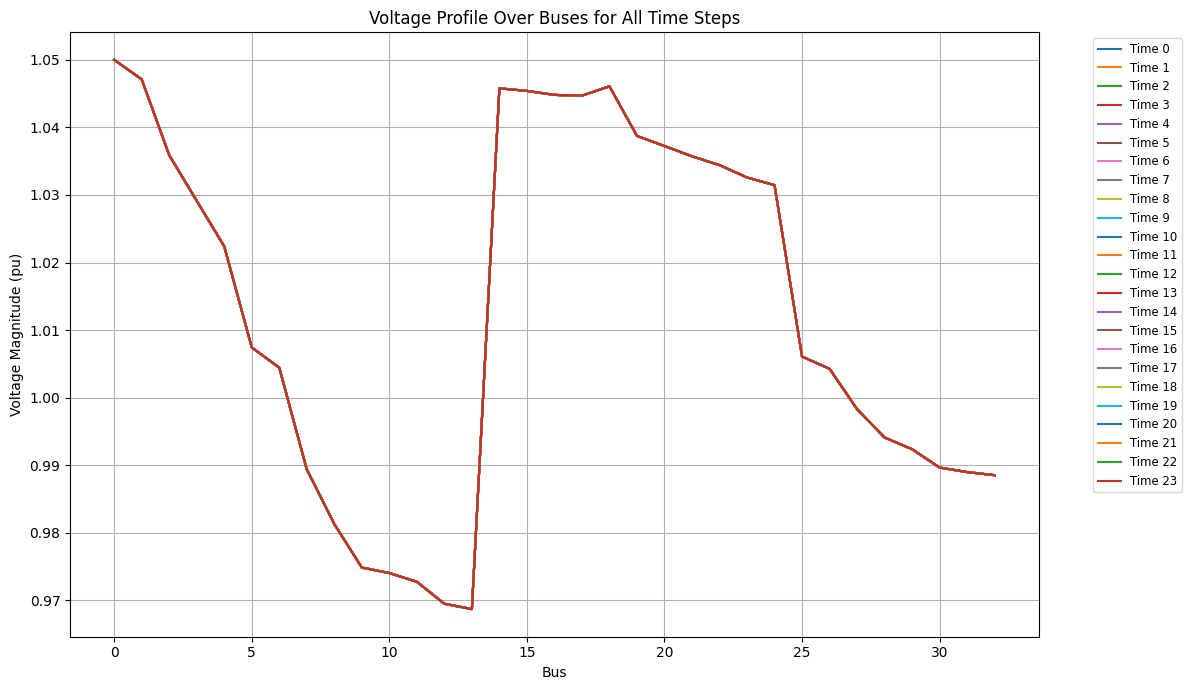

In [33]:
opt_model.plot_voltage()

In [34]:
spot_prices_all = pd.read_csv(r"Data\nordpool_2022-202506_15min.csv", index_col= [0])
building_data = pd.read_excel(r'Data\Building_test_data.xlsx', index_col = [0], sheet_name=None)
charging_point_data = pd.read_excel(r'Data\Charging_point_test_data.xlsx', sheet_name=None)
spot_prices_all.index = pd.to_datetime(spot_prices_all.index)
spot_prices_hourly = spot_prices_all.resample('h').mean()

In [35]:
start_date = pd.to_datetime("2023-01-01")
days = 5
horizon_hours = 36
store_hours = 24
previous_monthly_peak = 0
current_month=1
previous_soc = pd.DataFrame(index=range(1), columns=list(building_data.keys()))
previous_soc.iloc[:, :] = 0.5

# Store rolling results
rolling_results = pd.DataFrame()

# Track ongoing EV sessions across days
ongoing_sessions = {cp_name: [] for cp_name in charging_point_data.keys()}

for day in range(days):
    print("=" * 40)
    print(f"🔄 Day {day + 1} Optimization (36h Horizon)")

    #start_day = day + 1
    start_time = start_date + timedelta(days=day)
    end_time = start_time + timedelta(hours=horizon_hours)

    # 1. Build buildings
    print("Step 1: Initializing buildings")
    building_list = []
    for name in building_data.keys():
        load = building_data[name].loc[start_time:end_time - timedelta(hours=1), 'electricity_load']
        pv = building_data[name].loc[start_time:end_time - timedelta(hours=1), 'pv_production']
        bus = building_data[name].loc[end_time - timedelta(hours=1), 'bus']
        bess_capacity = 100 if name == 'B1' else 20
        bess_max_power = 15 if name == 'B1' else 11
        
        print(f"  - Building {name} with initial SOC {previous_soc[name].iloc[0]}")
        building_list.append(building(
            name=name,
            bus = bus,
            load=load,
            pv_production=pv,
            bess_capacity=bess_capacity,
            bess_initial_soc=previous_soc[name].iloc[0],
            bess_max_power=bess_max_power
        ))

    # 2. Charging Points
    print("Step 2: Preparing charging points")
    charging_point_list = []
    new_ongoing_sessions = {cp_name: [] for cp_name in charging_point_data.keys()}
    new_sessions_starting_tomorrow = []

    for cp_name in charging_point_data.keys():
        print(f"  ⛽ Charging Point: {cp_name}")
        cp_df = charging_point_data[cp_name]
        capacities, max_powers, arrivals, departures = [], [], [], []
        arrival_socs, desired_socs = [], []
        buses = 0

        # a) Add ongoing sessions
        print("   ↪ Checking ongoing sessions from previous day")
        for idx, session in enumerate(ongoing_sessions[cp_name]):
            if session['departure_time'] > start_time:
                dep_hour = int((session['departure_time'] - start_time).total_seconds() // 3600)
                ev_index = len(capacities)
                session['ev_index'] = ev_index
                capacities.append(session['capacity'])
                max_powers.append(session['max_power'])
                arrivals.append(0)
                departures.append(min(dep_hour, horizon_hours))
                arrival_socs.append(session['last_soc'])
                desired_socs.append(session['desired_soc'])
                buses = session['bus']

                print(f"     ✅ Continued EV{idx}: dep_hour={dep_hour}, SOC={session['last_soc']}")
                if session['departure_time'] > end_time:
                    new_ongoing_sessions[cp_name].append(session)

        # b) Add new sessions that start in first 24 hours
        print("   ↪ Adding new sessions starting in first 24 hours")
        today_sessions = cp_df[
            (cp_df['Arrival'] >= start_time) &
            (cp_df['Arrival'] < start_time + timedelta(hours=store_hours))
        ]

        for idx, row in today_sessions.iterrows():
            arrival_hour = int((row['Arrival'] - start_time).total_seconds() // 3600)
            departure_hour = int((row['Departure'] - start_time).total_seconds() // 3600)

            capacities.append(row['Capacity'])
            max_powers.append(row['Max_Power'])
            arrivals.append(arrival_hour)
            buses = row['bus']

            if row['Departure'] > end_time:
                departures.append(horizon_hours)
                session = {
                    'capacity': row['Capacity'],
                    'max_power': row['Max_Power'],
                    'departure_time': row['Departure'],
                    'last_soc': None,
                    'desired_soc': row['Desired SOC'],
                    'cp_name': cp_name,
                    'ev_index': len(capacities) - 1,
                    'bus': row['bus']
                }
                new_ongoing_sessions[cp_name].append(session)
                new_sessions_starting_tomorrow.append(session)
                print(f"     ➕ New EV (spans days): arrival {arrival_hour}, will depart next day")
            else:
                departures.append(departure_hour)
                print(f"     ➕ New EV: arrival {arrival_hour}, departure {departure_hour}")

            arrival_socs.append(row['Arrival SOC'])
            desired_socs.append(row['Desired SOC'])

        charging_point_list.append(charging_point(
            name=cp_name,
            bus = buses,
            ev_capacity=capacities,
            ev_max_power=max_powers,
            ev_arrival=arrivals,
            ev_departure=departures,
            ev_arrival_soc=arrival_socs,
            ev_desired_soc=desired_socs
        ))

    # 3. Run optimization
    print("Step 3: Solving optimization model")
    spot_prices = spot_prices_hourly.loc[start_time:end_time - timedelta(hours=1), 'SEK_per_kWh'].tolist()
    opt_model = V2G_opt_spot_cp_ldf(charging_point_list, building_list, spot_prices)
    results_df = opt_model.solve()
    df, df_voltage = opt_model.get_results()
    df.index = spot_prices_hourly.loc[start_time:end_time - timedelta(hours=1), 'SEK_per_kWh'].index

    print("   ✅ Optimization complete")
    for col in df.columns:
        if '_soc' in col:
            print(col, "→", df[col].iloc[store_hours - 1])
    print("\n✅ Columns in results DataFrame:")
    print([col for col in df.columns if '_soc' in col])

    # Save first 24h of results
    print("Step 3.5: Saving 24h results to cumulative DataFrame")
    rolling_results = pd.concat([rolling_results, df.iloc[:store_hours]])
    opt_month = rolling_results.index[-1].month
    if current_month - opt_month == 0:
        opt_peak = (df['P_import'].iloc[:24] - df['P_export'].iloc[:24]).max()   #needs to be from the opt
        if previous_monthly_peak < opt_peak:
            previous_monthly_peak = opt_peak
    else:
        previous_monthly_peak = 0
        current_month = opt_month
    # 4. Update building SOCs
    print("Step 4: Updating building SOCs")
    for name in building_data.keys():
        soc_val = df[f'{name}_bess_soc'].iloc[store_hours - 1]
        previous_soc[name].iloc[0] = soc_val
        print(f"  🔋 {name} end-of-day SOC: {soc_val:.2f}")

    # 5. Update ongoing sessions' SOCs
    print("Step 5: Updating ongoing session SOCs from Day", day + 1)
    for cp_name in ongoing_sessions.keys():
        for session in ongoing_sessions[cp_name]:
            ev_name = f"{session['cp_name']}_ev{session['ev_index']}"
            if ev_name + "_soc" in df.columns:
                session['last_soc'] = df[f'{ev_name}_soc'].iloc[store_hours - 1]
                print(f"🔄 Updated {ev_name} SOC = {session['last_soc']:.2f}")
            else:
                print(f"⚠️ Warning: {ev_name}_soc not found in results")

    # 6. Update new sessions for tomorrow with today’s end SOC
    print("Step 6: Updating sessions starting today that continue to tomorrow")
    for session in new_sessions_starting_tomorrow:
        ev_name = f"{session['cp_name']}_ev{session['ev_index']}"
        if f'{ev_name}_soc' in df.columns:
            session['last_soc'] = df[f'{ev_name}_soc'].iloc[store_hours - 1]
            print(f"🚚 {ev_name}: SOC carried to next day = {session['last_soc']:.2f}")
        else:
            print(f"⚠️ Could not update SOC for {ev_name}")

    # 7. Carry forward ongoing sessions
    print("Step 7: Updating ongoing_sessions for next day")
    ongoing_sessions = new_ongoing_sessions

    print("=" * 40 + "\n")
peak_load = (rolling_results['P_import']-rolling_results['P_export']).resample('M').max()
monthly_peak_costs = peak_load * 61.533 / 30 / 24
month_end_index = rolling_results.index.to_period('M').to_timestamp('M')
rolling_results['Peak cost'] = month_end_index.map(monthly_peak_costs)
rolling_results['DSO cost'] = 605/30/24 + rolling_results['Transmission cost'] + rolling_results['Peak cost']
rolling_results['Tax cost'] = 0.25 * (rolling_results['Supplier cost'] + rolling_results['DSO cost']) + 1.25 * 0.439 * (rolling_results['P_import'] - rolling_results['P_export'])
rolling_results['Overall cost'] = rolling_results['DSO cost'] + rolling_results['Supplier cost'] + rolling_results['Tax cost']

🔄 Day 1 Optimization (36h Horizon)
Step 1: Initializing buildings
  - Building B1 with initial SOC 0.5
  - Building B2 with initial SOC 0.5
Step 2: Preparing charging points
  ⛽ Charging Point: CP1
   ↪ Checking ongoing sessions from previous day
   ↪ Adding new sessions starting in first 24 hours
     ➕ New EV: arrival 1, departure 5
     ➕ New EV: arrival 7, departure 15
     ➕ New EV: arrival 18, departure 23
  ⛽ Charging Point: CP2
   ↪ Checking ongoing sessions from previous day
   ↪ Adding new sessions starting in first 24 hours
     ➕ New EV: arrival 1, departure 5
     ➕ New EV: arrival 7, departure 15
     ➕ New EV: arrival 18, departure 23
Step 3: Solving optimization model
Objective value: 422.45321880956
   ✅ Optimization complete
CP1_ev0_soc → 0.0
CP1_ev1_soc → 0.0
CP1_ev2_soc → 0.8
CP2_ev0_soc → 0.0
CP2_ev1_soc → 0.0
CP2_ev2_soc → 0.8
B1_bess_soc → 0.2641731698374028
B2_bess_soc → 0.2

✅ Columns in results DataFrame:
['CP1_ev0_soc', 'CP1_ev1_soc', 'CP1_ev2_soc', 'CP2_ev0_

In [36]:
rolling_results

,CP1_ev0_ch,CP1_ev0_ds,CP1_ev0_soc,CP1_ev1_ch,CP1_ev1_ds,CP1_ev1_soc,CP1_ev2_ch,CP1_ev2_ds,CP1_ev2_soc,CP1_P,...,B2_bess_soc,B2_P,P_import,P_export,Transmission cost,Supplier cost,Peak cost,DSO cost,Tax cost,Overall cost
datetime,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,0.000000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,-0.000000,...,0.500000,7.545000,19.730341,0.0,2.229529,0.505146,1.686204,4.756011,12.142314,17.403470
2023-01-01 01:00:00,0.000000,0.0,0.7000,0.0,0.0,0.0,0.0,0.0,0.0,-0.000000,...,0.968503,17.170341,19.730341,0.0,2.229529,0.377737,1.686204,4.756011,12.110462,17.244209
2023-01-01 02:00:00,0.000000,0.0,0.7000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.968503,6.335000,19.730341,0.0,2.229529,0.116853,1.686204,4.756011,12.045240,16.918104
2023-01-01 03:00:00,11.000000,0.0,0.9046,0.0,0.0,0.0,0.0,0.0,0.0,11.000000,...,0.968503,5.275000,19.730341,0.0,2.229529,0.114831,1.686204,4.756011,12.044735,16.915576
2023-01-01 04:00:00,5.129032,0.0,1.0000,0.0,0.0,0.0,0.0,0.0,0.0,5.129032,...,1.000000,6.257347,19.730341,0.0,2.229529,0.108764,1.686204,4.756011,12.043218,16.907992
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-01-05 19:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,0.634543,15.270000,15.594391,0.0,1.762166,27.844213,1.686204,4.288648,16.590637,48.723499
2023-01-05 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,0.386930,10.074391,15.594391,0.0,1.762166,25.660765,1.686204,4.288648,16.044775,45.994188
2023-01-05 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,0.250607,11.034391,15.594391,0.0,1.762166,23.833765,1.686204,4.288648,15.588025,43.710438
